# Matplotlib — Very Hard

## Rules
- Object-oriented Matplotlib only.
- Prefer explicit choices over defaults.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

## Exercise 1 — Multi-series with a highlighted segment

### Task
Reproduce the figure above.

### Constraints
- Show two noisy series and one smooth reference on the same plot area.
- Visually emphasize the portion of one series inside a given x-range.
- Use explicit axis limits and tick locations.
- Place a compact legend that remains readable.

In [3]:
x = np.linspace(0, 12, 360)
y_a = np.sin(x) + 0.18 * rng.normal(size=len(x))
y_b = 0.85 * np.sin(x + 0.55) + 0.18 * rng.normal(size=len(x))
y_ref = np.sin(x)  # noise-free reference


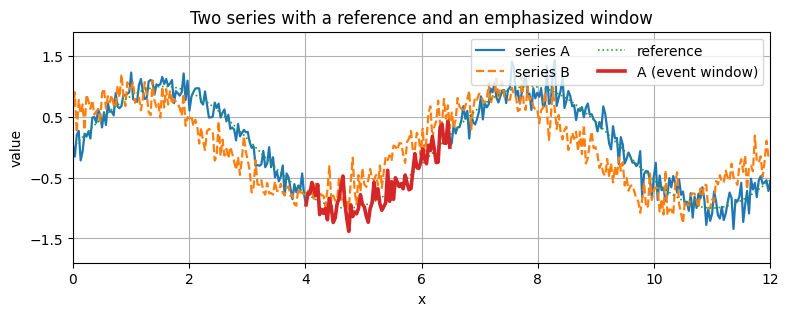

In [18]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(x, y_a, linewidth=1.6, label="series A")
ax.plot(x, y_b, linewidth=1.6, linestyle="--", label="series B")
ax.plot(x, y_ref, linewidth=1.2, linestyle=":", label="reference")

event_start, event_end = 4.0, 6.5

mask = (x >= event_start) & (x <= event_end)
ax.plot(x[mask], y_a[mask], linewidth=2.6, label="A (event window)")

ax.set_title("Two series with a reference and an emphasized window")
ax.set_xlabel("x")
ax.set_ylabel("value")

ax.set_xlim(0, 12)
ax.set_ylim(-1.9, 1.9)
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_yticks([-1.5, -0.5, 0.5, 1.5])

ax.grid(True)
ax.legend(loc="upper right", ncols=2)

plt.show()

## Exercise 2 — Scatter with a fixed color scale and flagged points

### Task
Reproduce the figure above.

### Constraints
- Use points to show the relationship between two variables.
- Encode a third variable via color using a fixed numeric range.
- Add a color scale with explicit tick locations.
- Visually distinguish a provided subset of points without changing the base scatter.
- Use explicit axis limits and ticks.

In [5]:
n = 260
xs = rng.normal(loc=0.0, scale=1.0, size=n)
ys = 0.75 * xs + rng.normal(loc=0.0, scale=0.85, size=n)
z = rng.normal(loc=50, scale=14, size=n)

# Inject a few outliers deterministically
out_idx = np.array([15, 71, 133, 199, 241])
xs[out_idx] += np.array([2.2, -2.8, 2.6, -2.4, 3.0])
ys[out_idx] += np.array([3.4, -3.2, -3.8, 3.0, 3.6])
z[out_idx] += np.array([35, 28, 40, 22, 30])



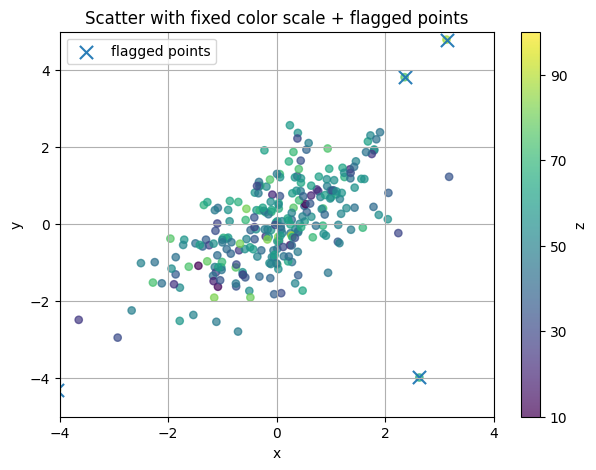

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(xs, ys, c=z, s=28, alpha=0.7, cmap="viridis", vmin=10, vmax=100)

ax.scatter(xs[out_idx], ys[out_idx], s=90, alpha=0.95, marker="x", label="flagged points")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("z")
cbar.set_ticks([10, 30, 50, 70, 90])

ax.set_title("Scatter with fixed color scale + flagged points")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.set_xlim(-4.0, 4.0)
ax.set_ylim(-5.0, 5.0)
ax.set_xticks([-4, -2, 0, 2, 4])
ax.set_yticks([-4, -2, 0, 2, 4])

ax.grid(True)
ax.legend(loc="upper left")

plt.show()

## Exercise 3 — Sorted bars with value labels

### Task
Reproduce the figure above.

### Constraints
- Display category totals as bars ordered from largest to smallest.
- Leave visible headroom above the tallest bar.
- Rotate category labels for readability.
- Display the numeric value above each bar and keep labels correctly centered.
- Include a light horizontal grid and a legend.

In [7]:
cats = ["A", "B", "C", "D", "E", "F", "G"]
counts = np.array([14, 8, 11, 5, 17, 9, 13])

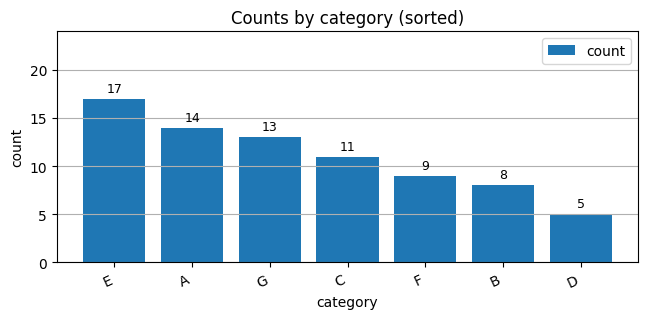

In [8]:
order = np.argsort(-counts)
cats_sorted = [cats[i] for i in order]
counts_sorted = counts[order]

fig, ax = plt.subplots(figsize=(7.5, 3))

bars = ax.bar(cats_sorted, counts_sorted, label="count")

ax.set_title("Counts by category (sorted)")
ax.set_xlabel("category")
ax.set_ylabel("count")

ax.set_ylim(0, int(counts_sorted.max()) + 7)
ax.set_yticks([0, 5, 10, 15, 20])

ax.set_xticks(range(len(cats_sorted)))
ax.set_xticklabels(cats_sorted, rotation=25, ha="right")

for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 0.4,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.grid(True, axis="y")
ax.legend(loc="upper right")

plt.show()

## Exercise 4 — Comparable histograms with mixed visual styles

### Task
Reproduce the figure above.

### Constraints
- Compare three distributions using identical bin edges.
- Use both filled and outline styles to keep overlap readable.
- Keep explicit axes limits and ticks.
- Place a compact legend that stays readable.

In [9]:
dist1 = rng.normal(loc=0.0, scale=1.0, size=700)
dist2 = rng.normal(loc=0.7, scale=1.25, size=700)
dist3 = rng.normal(loc=-0.4, scale=0.85, size=700)

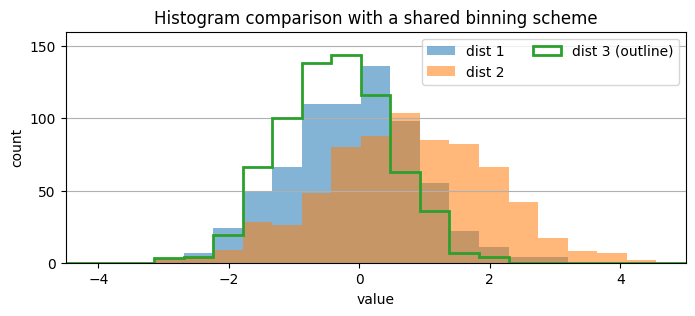

In [10]:
fig, ax = plt.subplots(figsize=(8, 3))

bins = np.linspace(-4.5, 5.0, 22)

ax.hist(dist1, bins=bins, alpha=0.55, label="dist 1")
ax.hist(dist2, bins=bins, alpha=0.55, label="dist 2")
ax.hist(dist3, bins=bins, histtype="step", linewidth=2.0, label="dist 3 (outline)")

ax.set_title("Histogram comparison with a shared binning scheme")
ax.set_xlabel("value")
ax.set_ylabel("count")

ax.set_xlim(-4.5, 5.0)
ax.set_xticks([-4, -2, 0, 2, 4])
ax.set_ylim(0, 160)
ax.set_yticks([0, 50, 100, 150])

ax.grid(True, axis="y")
ax.legend(loc="upper right", ncols=2)

plt.show()

## Exercise 5 — Thresholds, highlighted window, and a corner badge

### Task
Reproduce the figure above.

### Constraints
- Add two horizontal target markers and a highlighted x-range.
- Add a short corner label inside a visible box that stays in place when rescaling.
- Ensure the context elements do not obscure the main data.
- Use explicit limits, ticks, and a compact legend.

In [11]:
event_start, event_end = 4.0, 6.5
threshold_hi = 0.75
threshold_lo = -0.75

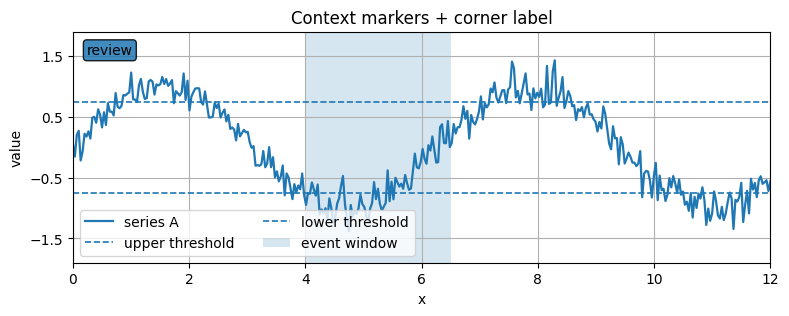

In [12]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(x, y_a, linewidth=1.6, label="series A")

ax.axhline(threshold_hi, linestyle="--", linewidth=1.2, label="upper threshold")
ax.axhline(threshold_lo, linestyle="--", linewidth=1.2, label="lower threshold")
ax.axvspan(event_start, event_end, alpha=0.18, label="event window")

ax.text(
    0.02, 0.95, "review",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.85),
)

ax.set_title("Context markers + corner label")
ax.set_xlabel("x")
ax.set_ylabel("value")

ax.set_xlim(0, 12)
ax.set_ylim(-1.9, 1.9)
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_yticks([-1.5, -0.5, 0.5, 1.5])

ax.grid(True)
ax.legend(loc="lower left", ncols=2)

plt.show()

## Exercise 6 — Multi-panel figure with consistent decisions

### Task
Reproduce the figure above.

### Constraints
- Create a 2×2 multi-panel figure containing: lines, a colored scatter, bars, and a histogram.
- Make the styling decisions consistent across panels (limits, ticks, grids).
- Add a single color scale attached to the correct panel.
- Use a figure-level title and avoid clipped labels.

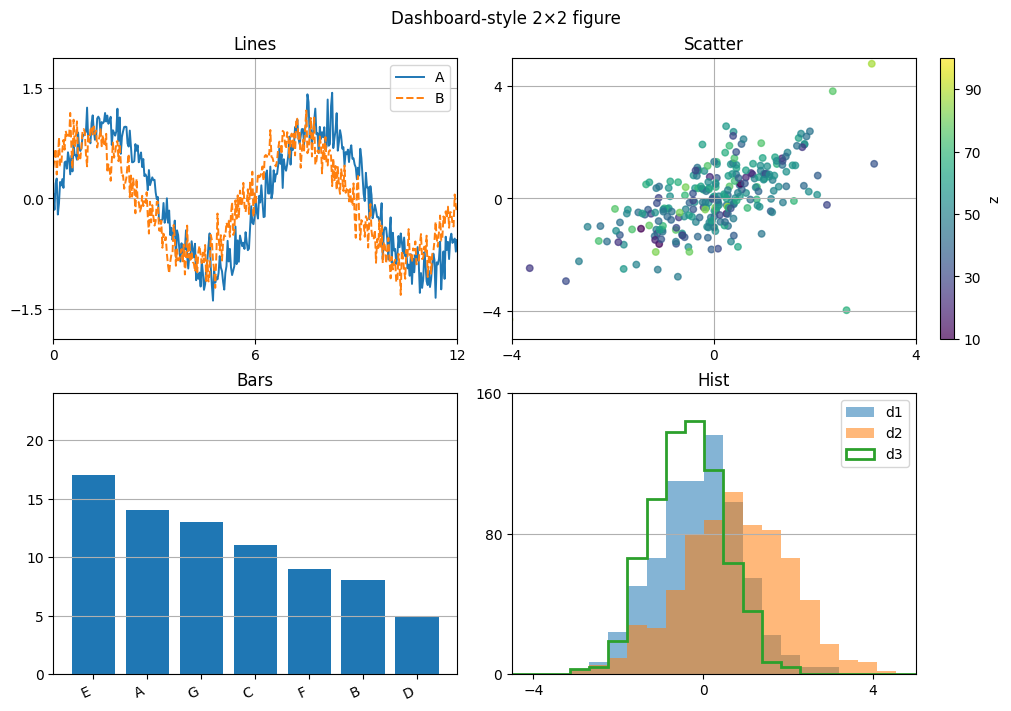

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False, constrained_layout=True)

ax = axs[0, 0]
ax.plot(x, y_a, linewidth=1.4, label="A")
ax.plot(x, y_b, linewidth=1.4, linestyle="--", label="B")
ax.set_title("Lines")
ax.set_xlim(0, 12)
ax.set_ylim(-1.9, 1.9)
ax.set_xticks([0, 6, 12])
ax.set_yticks([-1.5, 0.0, 1.5])
ax.grid(True)
ax.legend(loc="upper right")

ax = axs[0, 1]
sc = ax.scatter(xs, ys, c=z, s=22, alpha=0.7, cmap="viridis", vmin=10, vmax=100)
ax.set_title("Scatter")
ax.set_xlim(-4.0, 4.0)
ax.set_ylim(-5.0, 5.0)
ax.set_xticks([-4, 0, 4])
ax.set_yticks([-4, 0, 4])
ax.grid(True)

ax = axs[1, 0]
order = np.argsort(-counts)
cats_sorted = [cats[i] for i in order]
counts_sorted = counts[order]
ax.bar(cats_sorted, counts_sorted)
ax.set_title("Bars")
ax.set_ylim(0, int(counts_sorted.max()) + 7)
ax.set_xticks(range(len(cats_sorted)))
ax.set_xticklabels(cats_sorted, rotation=25, ha="right")
ax.grid(True, axis="y")

ax = axs[1, 1]
bins = np.linspace(-4.5, 5.0, 22)
ax.hist(dist1, bins=bins, alpha=0.55, label="d1")
ax.hist(dist2, bins=bins, alpha=0.55, label="d2")
ax.hist(dist3, bins=bins, histtype="step", linewidth=2.0, label="d3")
ax.set_title("Hist")
ax.set_xlim(-4.5, 5.0)
ax.set_xticks([-4, 0, 4])
ax.set_ylim(0, 160)
ax.set_yticks([0, 80, 160])
ax.grid(True, axis="y")
ax.legend(loc="upper right")

fig.suptitle("Dashboard-style 2×2 figure", fontsize=12)

cbar = fig.colorbar(sc, ax=axs[0, 1])
cbar.set_label("z")
cbar.set_ticks([10, 30, 50, 70, 90])

plt.show()

## Exercise 7 — Stacked bars with total labels

### Task
Reproduce the figure above.

### Constraints
- Show two components per category as a stacked total.
- Display the overall total above each stacked bar.
- Keep explicit scale, ticks, rotated labels, and a legend.
- Total labels must remain correctly placed if values change.

In [14]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = np.array([120, 90, 140, 110, 160, 130])
costs = np.array([70, 55, 85, 65, 95, 80])

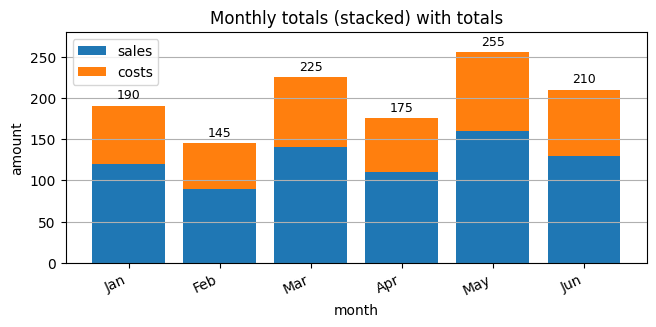

In [15]:
totals = sales + costs

fig, ax = plt.subplots(figsize=(7.5, 3))

ax.bar(months, sales, label="sales")
ax.bar(months, costs, bottom=sales, label="costs")

ax.set_title("Monthly totals (stacked) with totals")
ax.set_xlabel("month")
ax.set_ylabel("amount")

ax.set_ylim(0, 280)
ax.set_yticks([0, 50, 100, 150, 200, 250])

ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=25, ha="right")

for i, t in enumerate(totals):
    ax.text(i, t + 5, f"{int(t)}", ha="center", va="bottom", fontsize=9)

ax.grid(True, axis="y")
ax.legend(loc="upper left")

plt.show()

## Exercise 8 — Layout-tied label with collision avoidance

### Task
Reproduce the figure above.

### Constraints
- Add a short label in a fixed plot-area corner inside a visible box.
- Ensure the label and legend do not overlap.
- Use explicit limits, ticks, and a grid.

In [16]:
x = np.linspace(0, 12, 360)
y_b = 0.85 * np.sin(x + 0.55) + 0.18 * rng.normal(size=len(x))


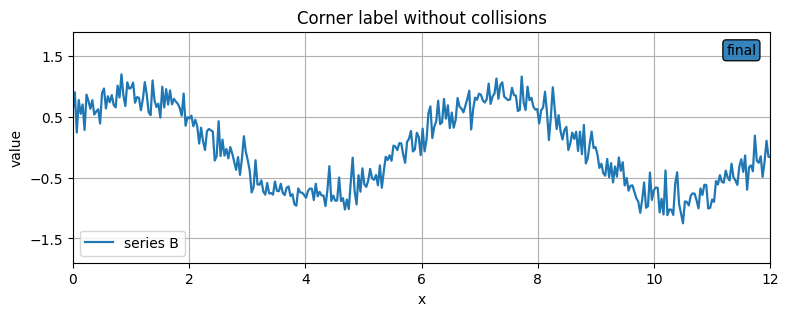

In [17]:
fig, ax = plt.subplots(figsize=(9, 3))

ax.plot(x, y_b, linewidth=1.6, label="series B")

ax.set_title("Corner label without collisions")
ax.set_xlabel("x")
ax.set_ylabel("value")

ax.set_xlim(0, 12)
ax.set_ylim(-1.9, 1.9)
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_yticks([-1.5, -0.5, 0.5, 1.5])

ax.text(
    0.98, 0.95, "final",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.25", alpha=0.9),
)

ax.grid(True)
ax.legend(loc="lower left")

plt.show()